In [1]:
import os
import sys
import pandas as pd

from pathlib import Path
sys.path.append("../")
from src.io import read_parameters

In [2]:
# read parameters and key file

parameter_file  = "/media/jpa/Volume/MDC/MDC_data/ec_tracking/trial/parameters_test_set.yml"
parameters = read_parameters(parameter_file)        

output_folder = Path(parameters["output_folder"])

if not os.path.exists(output_folder.joinpath("quality_control")):
    os.mkdir(output_folder.joinpath("quality_control"))

key_file_path = parameters["key_file"]
key_file = pd.read_csv(key_file_path)
print(key_file.head())

  experimentID                                           filename  color  \
0      D2_rep1  timecorrected_Chan1-ltorrotated-resized-D2_spo...  black   
1      E7_rep2  timecorrected_Chan1-ltorrotated-resized-E7_flo...  black   
2      D1_rep1  timecorrected_Chan1-ltorrotated-resized-D1_spo...  black   
3      G1_rep1  timecorrected_Chan1-ltorrotated-resized-G1_flo...    red   

             treatment_old                     treatment   condition  \
0          siCtrl+highVEGF          siCtrl+highVEGF-Flow  Flow-siRNA   
1          siCtrl+highVEGF          siCtrl+highVEGF-Flow  Flow-siRNA   
2          siCtrl+highVEGF          siCtrl+highVEGF-Stat  Stat-siRNA   
3  siGENOMEsiKank1+lowVEGF  siGENOMEsiKank1+lowVEGF-Flow  Flow-siRNA   

   frame_per_hour        date  
0              10  05/03/2025  
1              10  13/03/2025  
2              10  05/03/2025  
3              10  22/04/2025  


Plot quality control for file  timecorrected_Chan1-ltorrotated-resized-D2_spots.csv


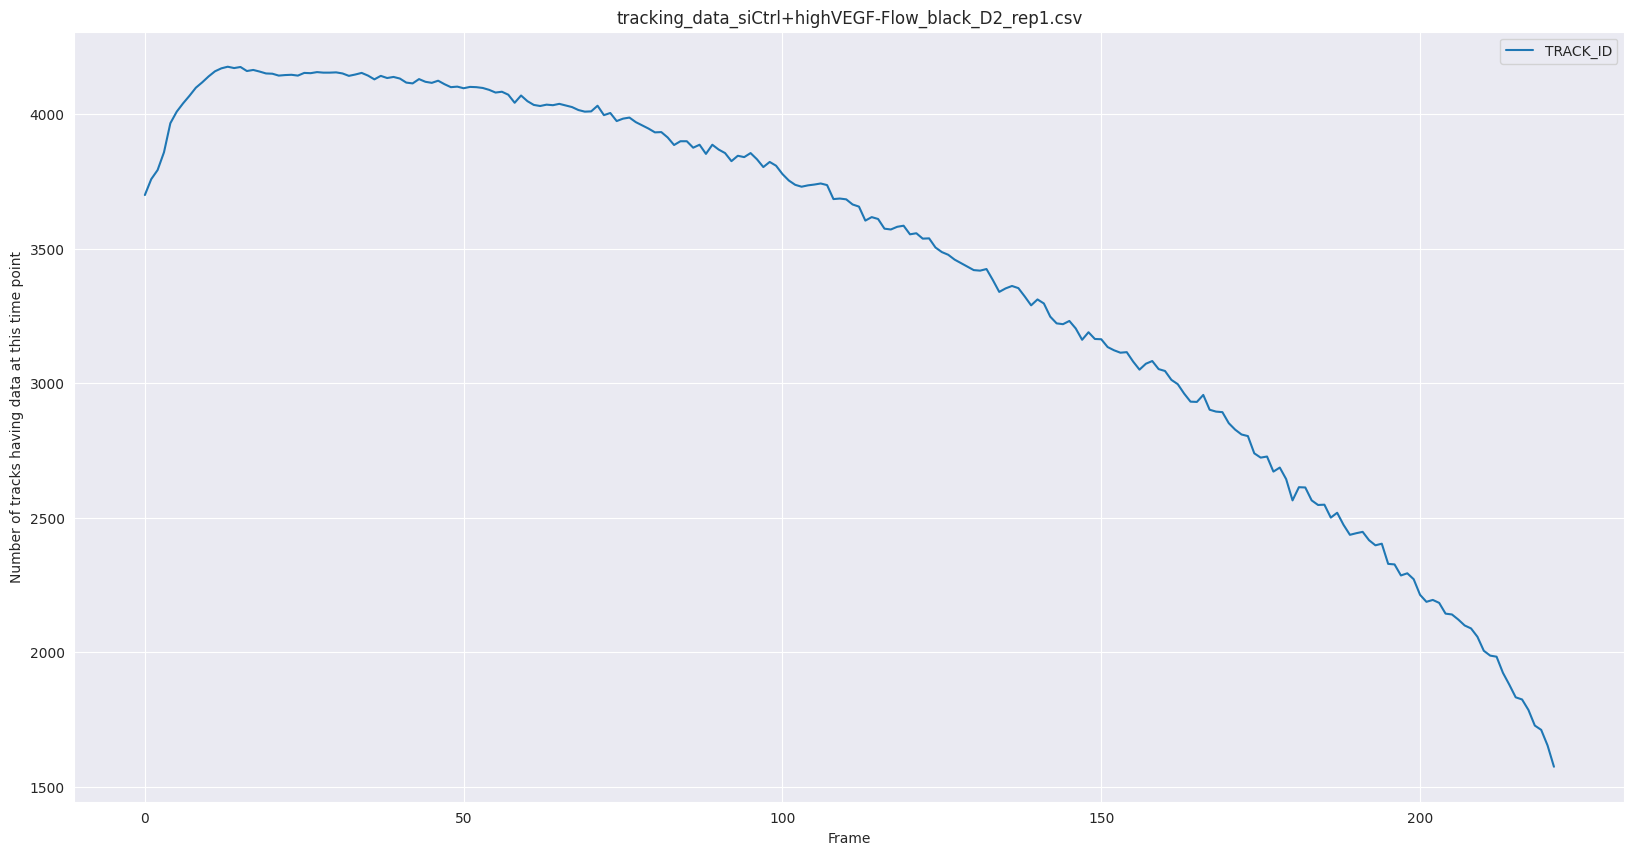

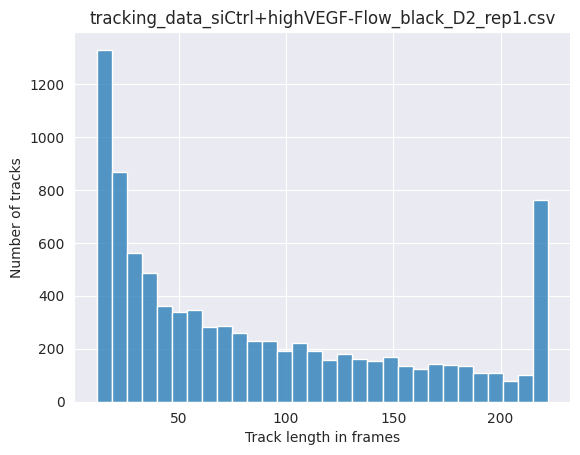

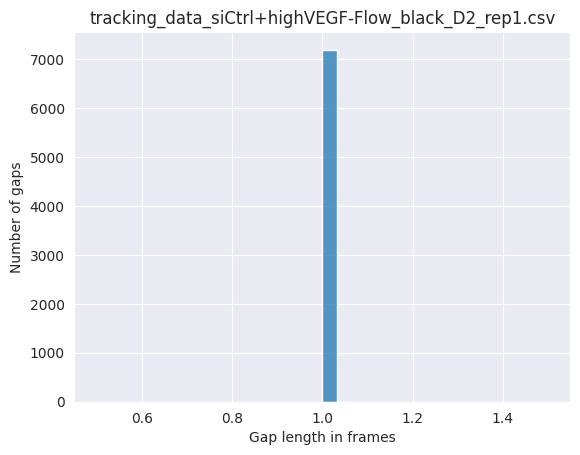

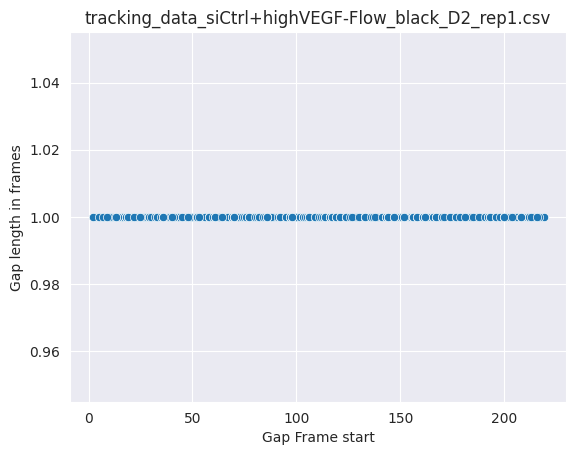

Plot quality control for file  timecorrected_Chan1-ltorrotated-resized-E7_flow-up_spots.csv


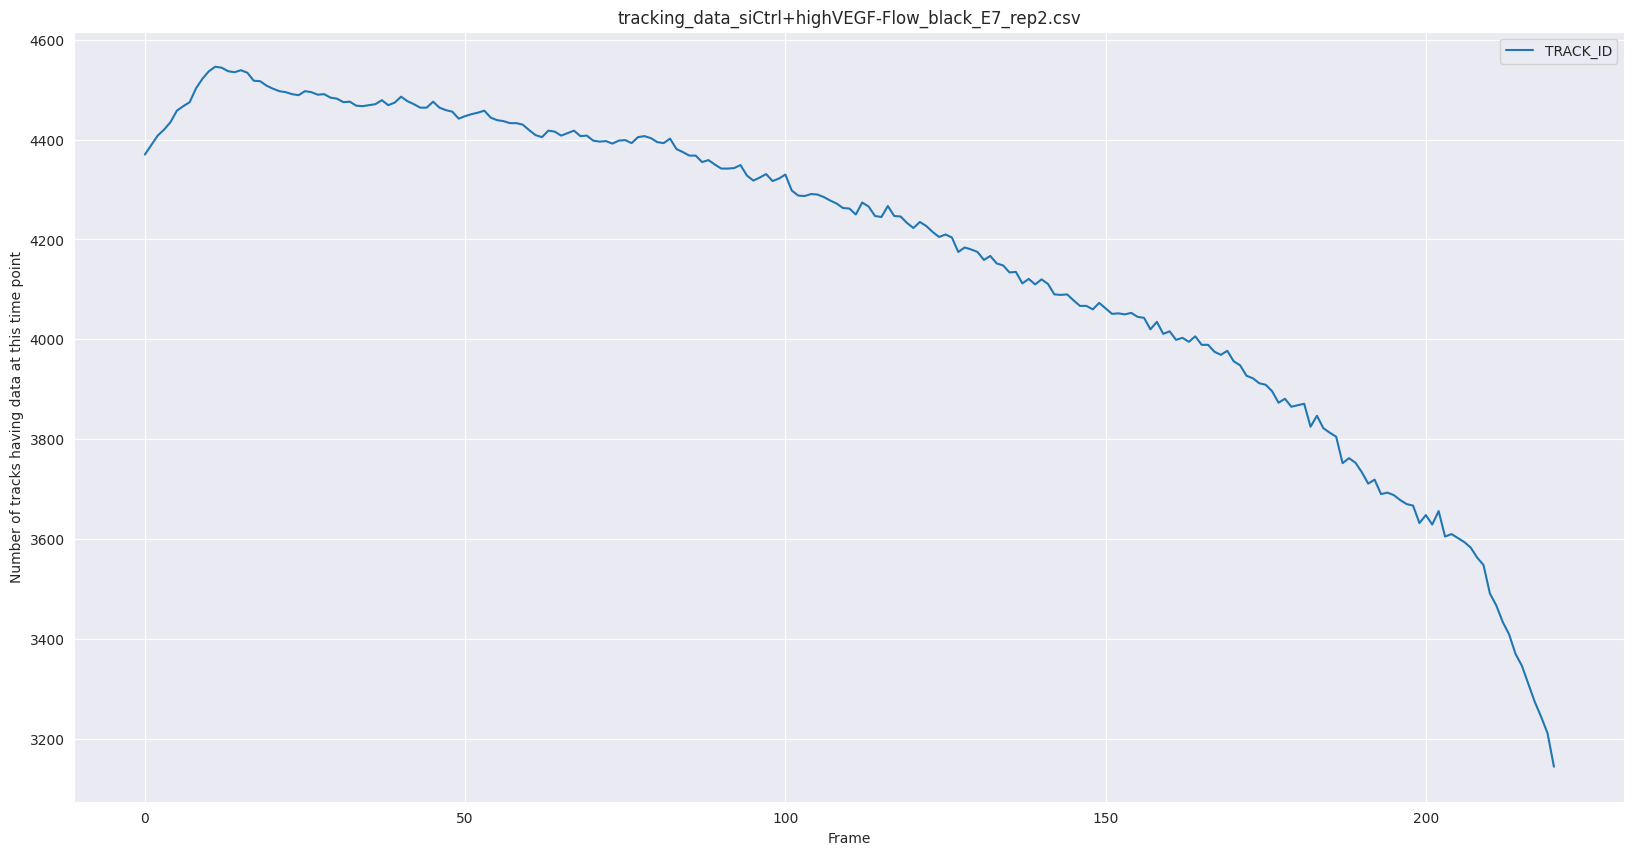

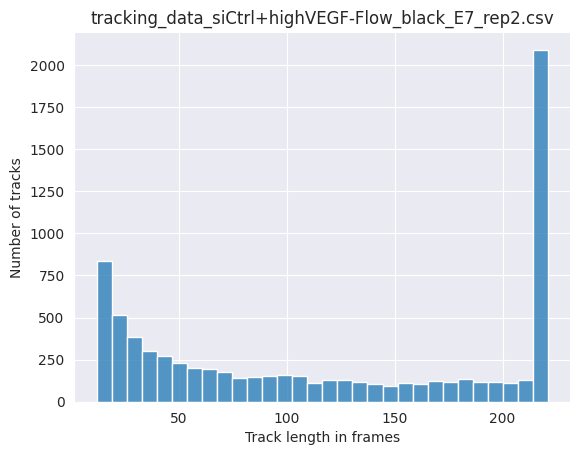

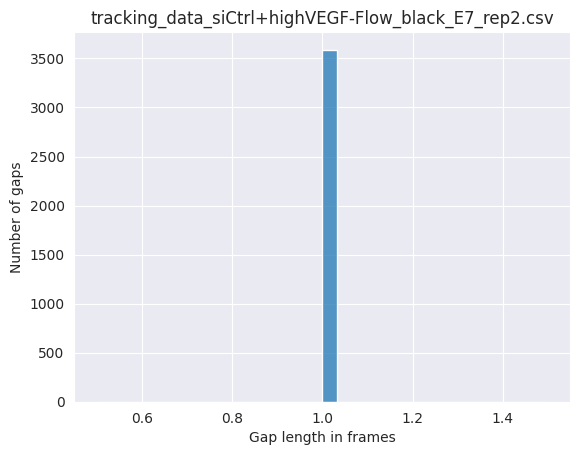

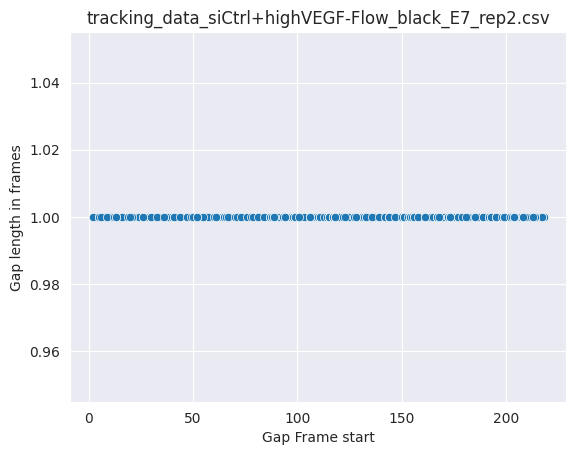

Plot quality control for file  timecorrected_Chan1-ltorrotated-resized-D1_spots.csv


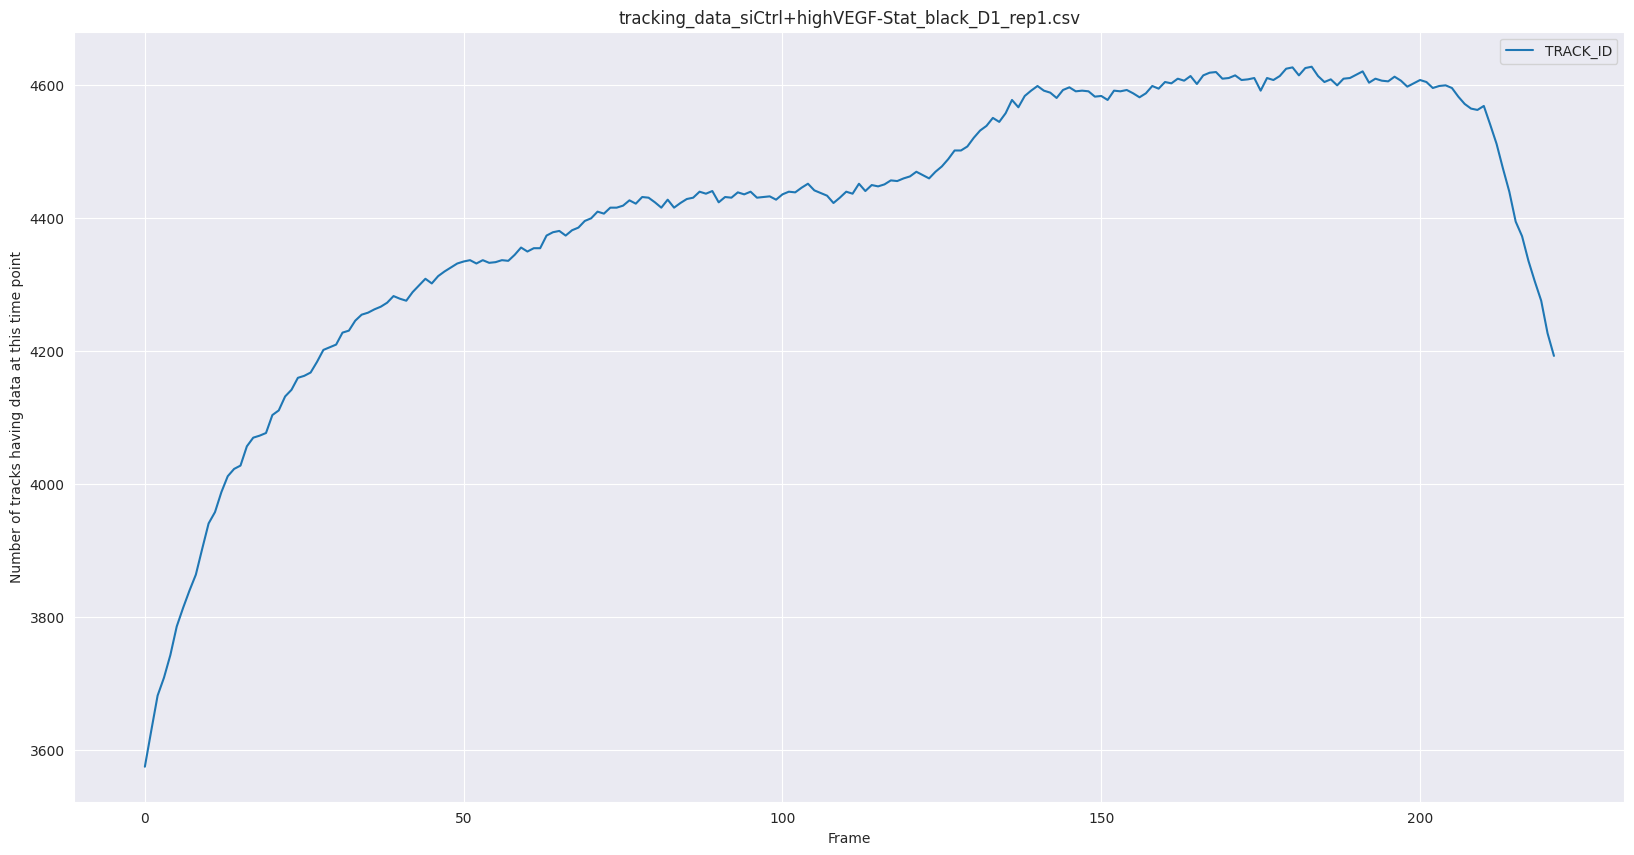

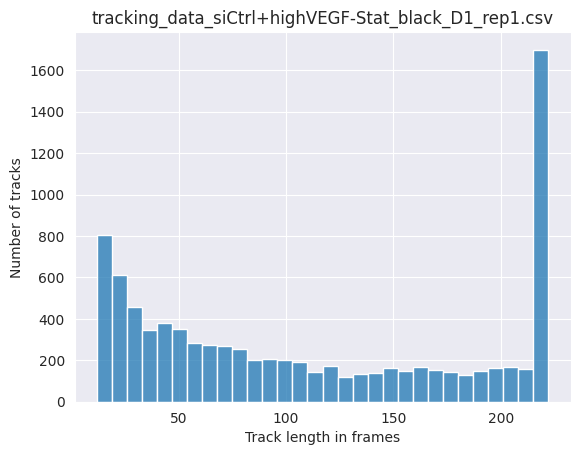

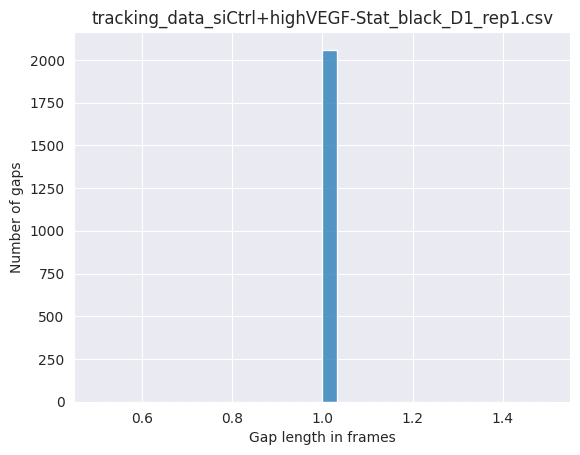

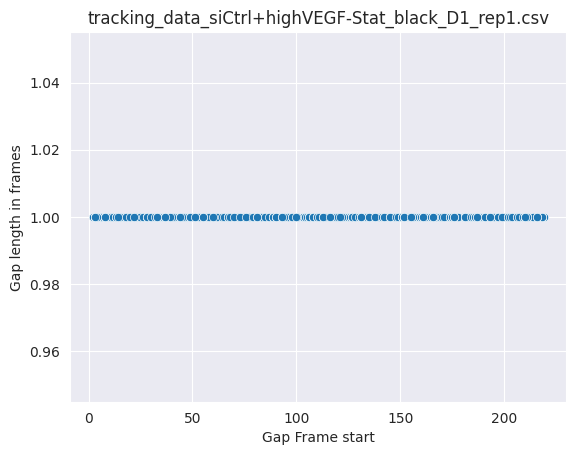

Plot quality control for file  timecorrected_Chan1-ltorrotated-resized-G1_flow_up_spots.csv


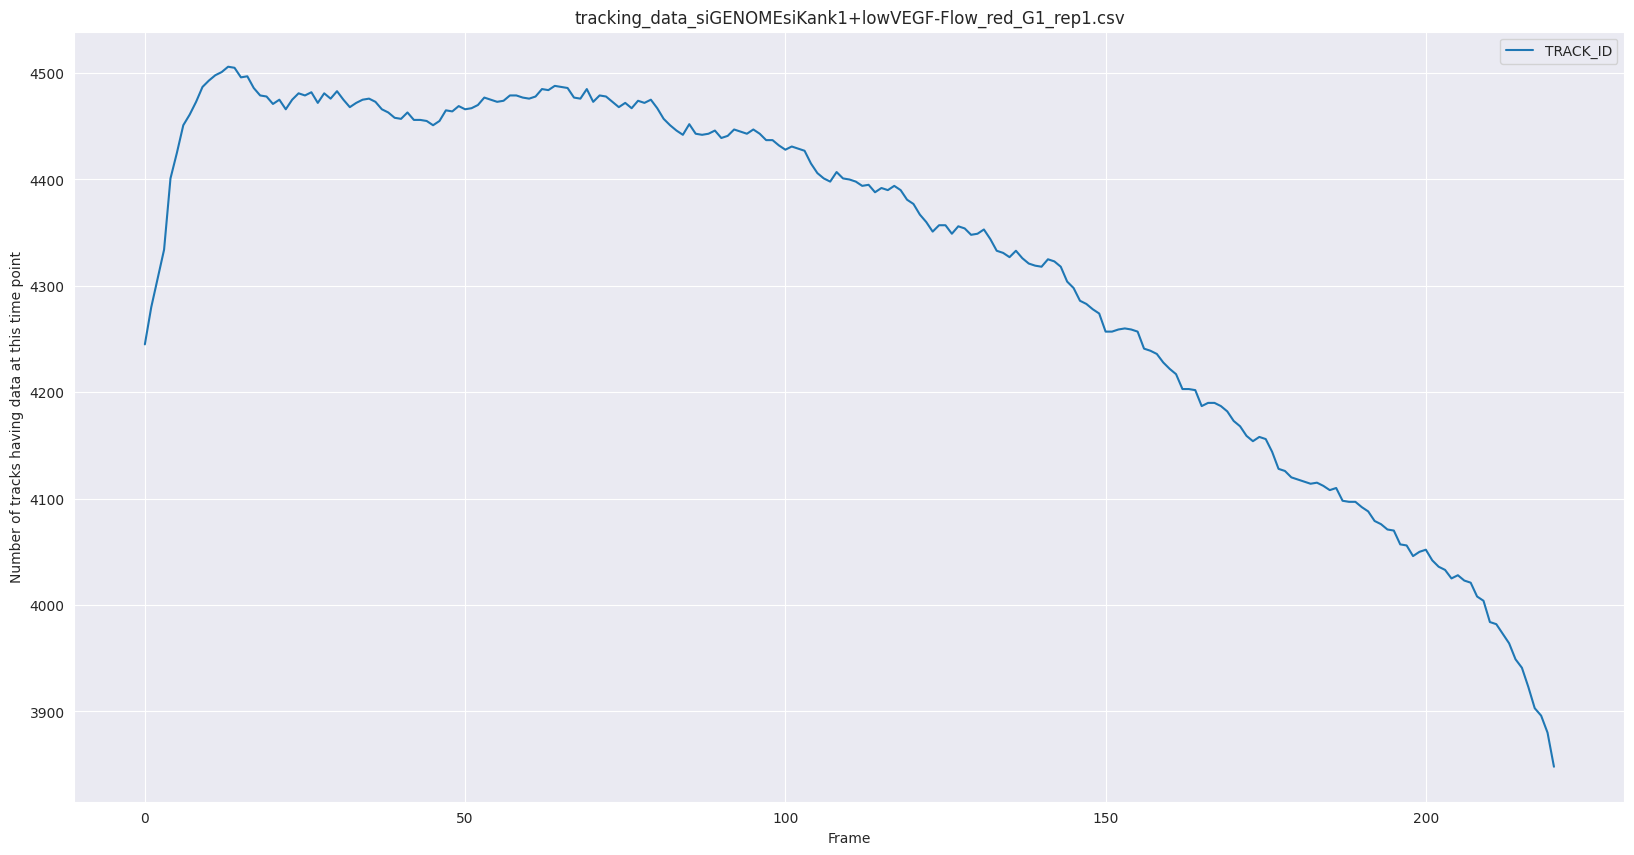

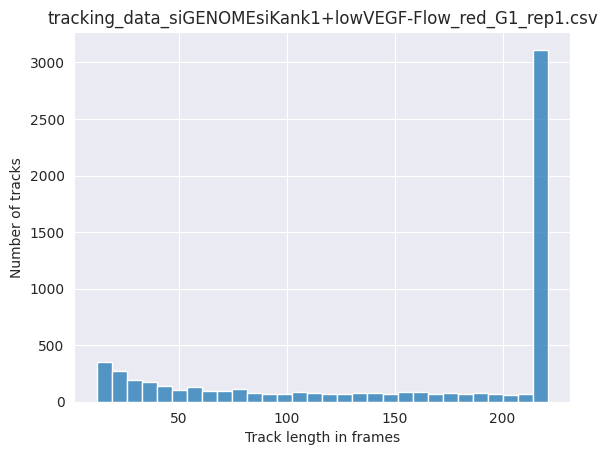

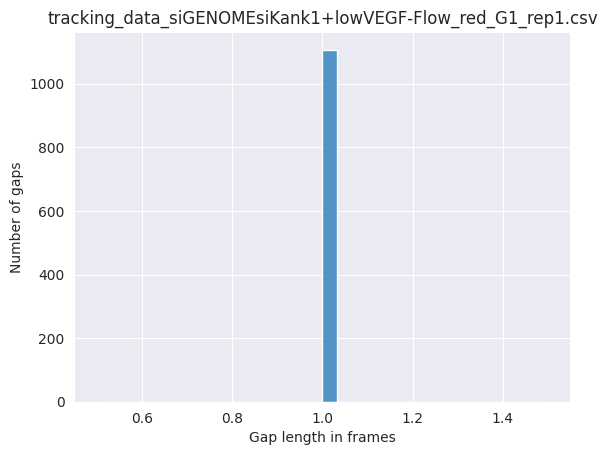

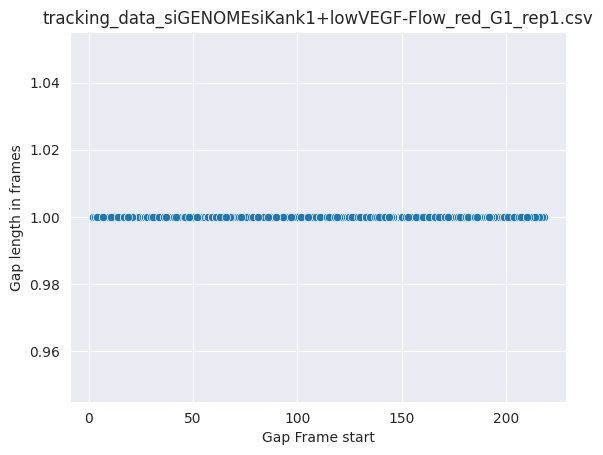

In [17]:
import numpy as np
def gaps_for_track(frames: pd.Series) -> pd.DataFrame:
        # sorted unique frames for this track
        arr = np.sort(frames.unique())
        if arr.size < 2:
            return pd.DataFrame(columns=['gap_start', 'gap_end', 'gap_length'])

        prev = arr[:-1]
        curr = arr[1:]
        gap_mask = (curr - prev) > 1

        if not np.any(gap_mask):
            return pd.DataFrame(columns=['gap_start', 'gap_end', 'gap_length'])

        starts = prev[gap_mask] + 1
        ends   = curr[gap_mask] - 1
        lengths = ends - starts + 1

        return pd.DataFrame({
            'gap_start': starts,
            'gap_end': ends,
            'gap_length': lengths
        })


def plot_quality_control(parameters, key_file, subfolder="tracking_data"):
    import matplotlib.pyplot as plt
    import seaborn as sns
    tracking_data_path = Path(parameters["output_folder"]).joinpath(subfolder)

    for index, row in key_file.iterrows():
        tracking_file = "tracking_data_%s_%s_%s.csv" % (row["treatment"], row["color"], row["experimentID"])
        print("Plot quality control for file ", row["filename"])
        data = pd.read_csv(tracking_data_path.joinpath(tracking_file), low_memory=False)

        # tracking_data_df_ = tracking_data_df[tracking_data_df["filename"] == filename]
        #fig, ax = plt.subplots(figsize=(20, 10))
        #sns.scatterplot(data=data, x="FRAME", y="TRACK_ID")
        #ax.set_title("Experiment ID %s" % row["experimentID"])

        #fig.savefig(
        #    Path(parameters["output_folder"]).joinpath("quality_control", "quality_control_%s_%s_%s.png" % (
        #        row["treatment"], row["color"], row["experimentID"]))
        #)

        #plt.show()

        # The inactive function below is taken from track_analysis.py, which is used to generate the second
        # quality control plot in the early code(the non numbered notebooks).
        # It line plots the total number of tracks that are available at the given time point.
        # It does not discriminate how long the tracks are, but can be used for checking fluorescence loss over time
        # Ideally to be called during 02_Quality_control, bit more useful than the previous function above imo

        fig, ax = plt.subplots(figsize=(20, 10))
        data[["FRAME", "TRACK_ID"]].groupby("FRAME").count().plot(ax=ax)
        ax.set_title(tracking_file)

        ax.set_xlabel("Frame")
        ax.set_ylabel("Number of tracks having data at this time point")

        fig.savefig(
            Path(parameters["output_folder"]).joinpath("quality_control", "quality_control2_%s_%s_%s.png" % (
                row["treatment"], row["color"], row["experimentID"]))
        )

        plt.show()



        # compute the maximum frame length per track ID
        track_length = data.groupby("TRACK_ID")["FRAME"].count().reset_index()
        
        fig, ax = plt.subplots()
        sns.histplot(data=track_length, x="FRAME", bins=30)
            
        ax.set_title(tracking_file)
        ax.set_xlabel("Track length in frames")
        ax.set_ylabel("Number of tracks")
        plt.show()


        fig.savefig(
            Path(parameters["output_folder"]).joinpath("quality_control", "quality_control3_%s_%s_%s.png" % (
                row["treatment"], row["color"], row["experimentID"]))
        )
        plt.show()
        
        
        # show number of gaps
        gaps = (data.groupby('TRACK_ID')['FRAME']
              .apply(gaps_for_track)
              .reset_index()
              .drop(columns='level_1')) 
        
        fig, ax = plt.subplots()
        sns.histplot(data=gaps, x="gap_length", bins=30)
        ax.set_title(tracking_file)
        ax.set_xlabel("Gap length in frames")
        ax.set_ylabel("Number of gaps")
        plt.show()
        
        # plot position of gaps over time
        fig, ax = plt.subplots()
        sns.scatterplot(data=gaps, x="gap_start", y="gap_length")
        ax.set_title(tracking_file)
        ax.set_xlabel("Gap Frame start")
        ax.set_ylabel("Gap length in frames")
        plt.show()
        

        
        
        
        
plot_quality_control(parameters, key_file)